In [15]:
# Imports
import numpy as np
import time
import torch
import matplotlib.pyplot as plt
from utils.loss_utils import (
    mse_loss, fluid_weighted_mse_loss, boundary_loss, PDE_loss,
    data_loss_fn, physics_loss_fn, boundary_loss_fn, compute_grad_norms
)
from utils.prepare_data import prepare_data, load_data, extract_fluid_region, sample_collocation_points, sample_boundary_points
from utils.utils import copy_cource_code, load_config, shutil
import SIREN
from configs.default import get_config
import csv

In [ ]:
config = get_config()

# Store source files
#copy_cource_code(config.log_dir, directory_to_backup= ["."])

# Load data
u, v, w, p, mask = load_data(config)

# Prepare data
uvw_data, xyz_data, mask_flat, boundary_mask_flat, standardization_factors  = prepare_data(config, u, v, w, p, mask)

print(uvw_data.shape)
print(xyz_data.shape)

if config.setup.expand_mask:
    mask_flat = mask_flat + boundary_mask_flat

# Include fluid region data
if config.setup.fluid_region:

    uvw_train, xyz_train = extract_fluid_region(uvw_data, xyz_data, mask_flat)
else:
    uvw_train, xyz_train = uvw_data, xyz_data


# Sample collocation points
if config.sample_collocation:
    xyz_collocation = sample_collocation_points(config, xyz_data, mask_flat)

# Sample boundary points
if config.sample_boundary:
    xyz_boundary = sample_boundary_points(config, xyz_data, boundary_mask_flat)


U SHAPE
(126, 81, 57, 50)
Ravel
(29087100,)
(29087100, 3)
(29087100, 4)


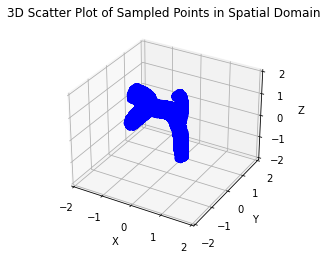

In [17]:
# Extract spatial coordinates
x_sampled = xyz_collocation[:, 1]
y_sampled = xyz_collocation[:, 2]
z_sampled = xyz_collocation[:, 3]

# Plotting the 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x_sampled, y_sampled, z_sampled, c='b', marker='o', alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter Plot of Sampled Points in Spatial Domain')

# Set new domain limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])

plt.show()

In [23]:
np.unique(xyz_data[:, 1]) 

array([-1.71079785e+00, -1.66802790e+00, -1.62525795e+00, -1.58248801e+00,
       -1.53971806e+00, -1.49694811e+00, -1.45417817e+00, -1.41140822e+00,
       -1.36863828e+00, -1.32586833e+00, -1.28309838e+00, -1.24032844e+00,
       -1.19755849e+00, -1.15478855e+00, -1.11201860e+00, -1.06924865e+00,
       -1.02647871e+00, -9.83708761e-01, -9.40938815e-01, -8.98168869e-01,
       -8.55398923e-01, -8.12628977e-01, -7.69859030e-01, -7.27089084e-01,
       -6.84319138e-01, -6.41549192e-01, -5.98779246e-01, -5.56009300e-01,
       -5.13239354e-01, -4.70469408e-01, -4.27699461e-01, -3.84929515e-01,
       -3.42159569e-01, -2.99389623e-01, -2.56619677e-01, -2.13849731e-01,
       -1.71079785e-01, -1.28309838e-01, -8.55398923e-02, -4.27699461e-02,
       -3.79873432e-16,  4.27699461e-02,  8.55398923e-02,  1.28309838e-01,
        1.71079785e-01,  2.13849731e-01,  2.56619677e-01,  2.99389623e-01,
        3.42159569e-01,  3.84929515e-01,  4.27699461e-01,  4.70469408e-01,
        5.13239354e-01,  

In [34]:
np.unique(xyz_data[:, 1])[29]


-0.47046940752256605

### Plot collocation & boundary points

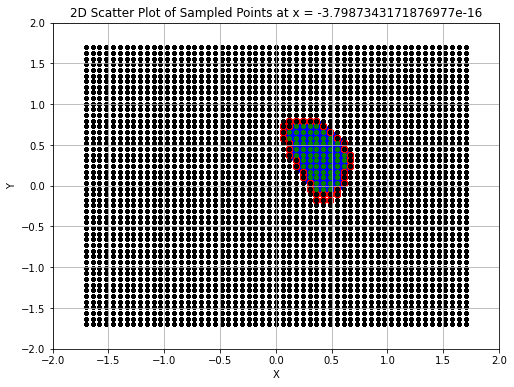

In [61]:
# Choose a specific z-coordinate value for slicing
#x_slice_value = -0.470469408 
x_slice_value = np.unique(xyz_data[:, 1])[40]

# Define a tolerance for filtering the z-coordinate
x_tolerance = 0.02  # Adjust this tolerance as needed

# Filter points based on the chosen z-coordinate slice
filtered_points = xyz_collocation[np.abs(xyz_collocation[:, 1] - x_slice_value) < x_tolerance]

# Extract y and z coordinates of the filtered points
x_sampled = filtered_points[:, 2]
y_sampled = filtered_points[:, 3]

# Plotting the 2D scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x_sampled, y_sampled, c='b', marker='o', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'2D Scatter Plot of Sampled Points at x = {x_slice_value}')

# Filter points based on the chosen z-coordinate slice
filtered_points_2 = xyz_boundary[np.abs(xyz_boundary[:, 1] - x_slice_value) < x_tolerance]

# Extract y and z coordinates of the filtered points
x_sampled_2 = filtered_points_2[:, 2]
y_sampled_2 = filtered_points_2[:, 3]

plt.scatter(x_sampled_2, y_sampled_2, c='r', marker='o', alpha=0.2)

# Filter points based on the chosen z-coordinate slice
filtered_points_3 = xyz_data[np.abs(xyz_data[:, 1] - x_slice_value) < x_tolerance]


# Extract y and z coordinates of the filtered points
x_sampled_3 = filtered_points_3[:, 2]
y_sampled_3 = filtered_points_3[:, 3]

plt.scatter(x_sampled_3, y_sampled_3, c='k', marker='.', alpha=0.1)

# Filter points based on the chosen z-coordinate slice
filtered_points_4 = xyz_train[np.abs(xyz_train[:, 1] - x_slice_value) < x_tolerance]

# Extract y and z coordinates of the filtered points
x_sampled_4 = filtered_points_4[:, 2]
y_sampled_4 = filtered_points_4[:, 3]

plt.scatter(x_sampled_4, y_sampled_4, c='g', marker='.', alpha=0.8)

# Set new domain limits
plt.xlim([-2, 2])
plt.ylim([-2, 2])

#plt.xlim([-1, 0])
#plt.ylim([0.5, 1.5])

plt.grid(True)
plt.show()

### Plot velocities

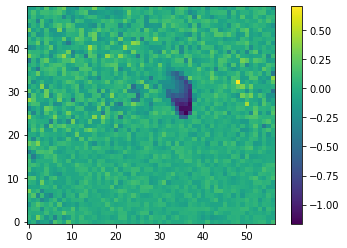

In [60]:
slice_t = 32
x_slice_value = 40

im = plt.imshow(u[slice_t, x_slice_value, :, :].T, cmap='viridis', origin='lower')
plt.colorbar(im)